In [1]:
!pip install -q torch scikit-learn pandas numpy matplotlib seaborn

Device: cuda
EBAMTN-STL | 24-Hour Forecasting | Delhi
Rows -> Train:52584  Val:1416  Test:744
Sequences -> Train:52393  Val:1225  Test:553
X shape: (52393, 168, 14)  y shape: (52393, 24, 2)

Training EBAMTN-STL-PM25 (24h ahead) ...
  Ep  20  train=0.00289  val=0.00409
  Early stop @ ep 30
  PM2.5 -> MAE=24.878  RMSE=32.131  R2=0.2800

Training EBAMTN-STL-PM10 (24h ahead) ...
  Early stop @ ep 20
  PM10  -> MAE=53.822  RMSE=70.952  R2=0.1594


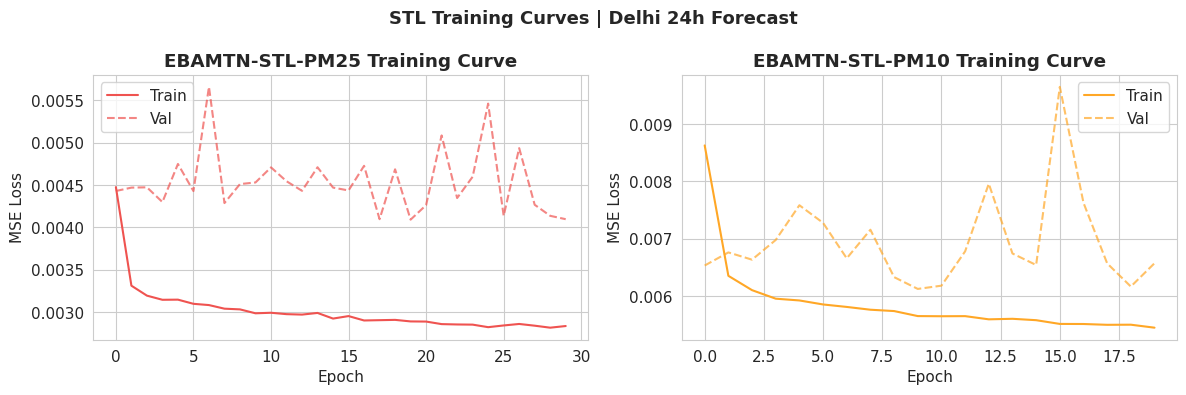

Saved: stl_training_curves.png


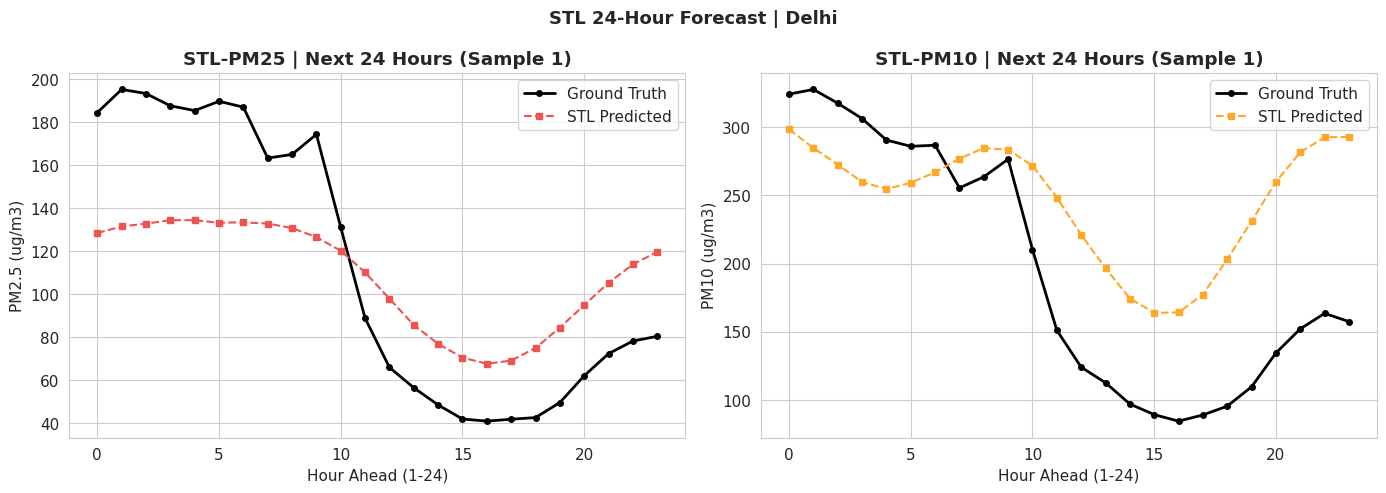

Saved: stl_24h_sample.png


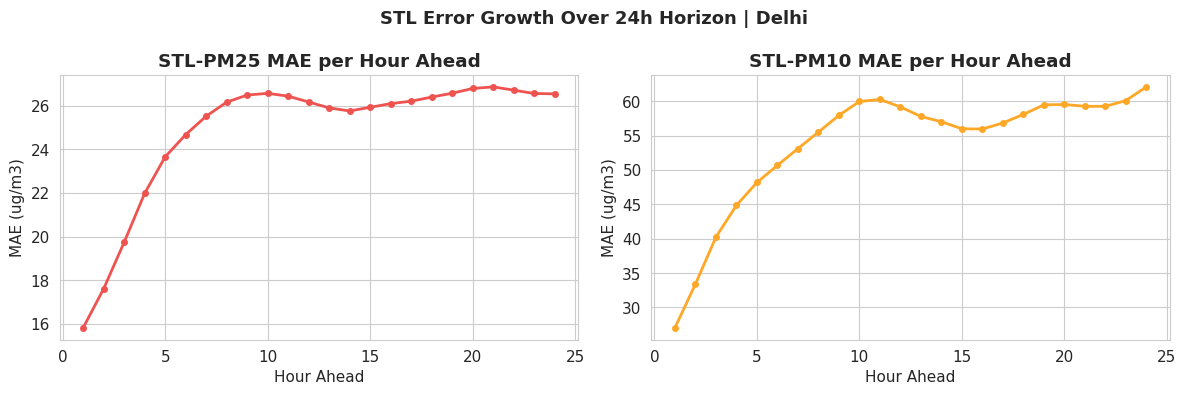

Saved: stl_mae_per_hour.png

STL done. Run Cell 2 for MTL.


In [ ]:
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

HORIZON = 24

CFG = dict(
    train_path    = "Train_data.csv",
    val_path      = "Validation_data.csv",
    test_path     = "Test_data.csv",
    feature_cols  = ["pm25","pm10","no","nh3","no2","nox",
                     "so2","co","ozone","bp","wind_speed",
                     "air_temp","humidity","rainfall"],
    target_cols   = ["pm25","pm10"],
    window_size   = 168,
    horizon       = HORIZON,
    batch_size    = 128,
    lr            = 1e-3,
    weight_decay  = 1e-4,
    epochs        = 100,
    patience      = 10,
    noise_factor  = 0.05,
    grad_clip     = 1.0,
    alpha         = 0.5,
    tcn_channels  = [32, 64, 128],
    bilstm_hidden = 64,
    bilstm_layers = 2,
    num_heads     = 4,
    fusion_dim    = 128,
    dropout       = 0.1,
)


def _sort(df):
    col = "from_date" if "from_date" in df.columns else "Date"
    df[col] = pd.to_datetime(df[col])
    return df.sort_values(col).reset_index(drop=True)

def load_splits(cfg):
    cols = cfg["feature_cols"]
    dfs  = [_sort(pd.read_csv(p))[cols].dropna().reset_index(drop=True)
            for p in (cfg["train_path"], cfg["val_path"], cfg["test_path"])]
    scalers = {}
    scaled = [np.zeros((len(df), len(cols)), dtype=np.float32) for df in dfs]
    for i, col in enumerate(cols):
        sc = MinMaxScaler()
        scaled[0][:,i] = sc.fit_transform(dfs[0][[col]]).flatten()
        scaled[1][:,i] = sc.transform(dfs[1][[col]]).flatten()
        scaled[2][:,i] = sc.transform(dfs[2][[col]]).flatten()
        scalers[col] = sc
    print(f"Rows -> Train:{len(scaled[0])}  Val:{len(scaled[1])}  Test:{len(scaled[2])}")
    return scaled[0], scaled[1], scaled[2], scalers, cols

def make_sequences(data, window, horizon, tgt_idx):
    X, y = [], []
    for i in range(window, len(data) - horizon + 1):
        X.append(data[i - window: i])
        y.append(data[i: i + horizon][:, tgt_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

class AQDataset(Dataset):
    def __init__(self, X, y, noise=0.0):
        self.X=torch.tensor(X); self.y=torch.tensor(y); self.noise=noise
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x = self.X[idx]
        if self.noise > 0: x = x + self.noise*torch.randn_like(x)
        return x, self.y[idx]

def make_loaders(X_tr,y_tr,X_va,y_va,X_te,y_te,cfg):
    kw = dict(batch_size=cfg["batch_size"], num_workers=0, pin_memory=True)
    return (DataLoader(AQDataset(X_tr,y_tr,cfg["noise_factor"]),shuffle=True, **kw),
            DataLoader(AQDataset(X_va,y_va), shuffle=False,**kw),
            DataLoader(AQDataset(X_te,y_te), shuffle=False,**kw))

class MultiScaleTCN(nn.Module):
    def __init__(self, in_ch, branch_ch=(32,64,128), dropout=0.1):
        super().__init__()
        branch_ch = list(branch_ch)
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv1d(in_ch,oc,k,padding=k//2),
                          nn.BatchNorm1d(oc),nn.ReLU(),nn.Dropout(dropout))
            for k,oc in zip([3,5,7],branch_ch)])
        self.total_ch = sum(branch_ch)
        self.score_fcs = nn.ModuleList([nn.Linear(oc,1) for oc in branch_ch])
        self.proj_convs = nn.ModuleList([nn.Conv1d(oc,self.total_ch,1) for oc in branch_ch])
        ch = self.total_ch
        self.dil_layers = nn.ModuleList([
            nn.Sequential(nn.Conv1d(ch,ch,3,padding=2**l,dilation=2**l),
                          nn.BatchNorm1d(ch),nn.ReLU(),nn.Dropout(dropout))
            for l in range(4)])
        self.skip_convs = nn.ModuleList([nn.Conv1d(ch,ch,1) for _ in range(4)])

    def forward(self, x):
        x = x.permute(0,2,1)
        bouts = [b(x) for b in self.branches]
        scores = torch.cat([fc(bo.mean(-1)) for fc,bo in zip(self.score_fcs,bouts)],dim=-1)
        weights = torch.softmax(scores,dim=-1)
        projs = [pc(bo) for pc,bo in zip(self.proj_convs,bouts)]
        fused = sum(weights[:,i:i+1].unsqueeze(-1)*projs[i] for i in range(len(self.branches)))
        h,skip_sum = fused,0
        for dl,sk in zip(self.dil_layers,self.skip_convs):
            h=dl(h)+h; skip_sum=skip_sum+sk(h)
        return skip_sum.permute(0,2,1)

class BiLSTMAttention(nn.Module):
    def __init__(self, in_dim, hidden=64, layers=2, heads=4, dropout=0.1):
        super().__init__()
        self.bilstm = nn.LSTM(in_dim,hidden,layers,batch_first=True,
                              bidirectional=True,dropout=dropout if layers>1 else 0)
        self.attn = nn.MultiheadAttention(hidden*2,heads,dropout=dropout,batch_first=True)
        self.gate = nn.Linear(hidden*4,hidden*2)
        self.proj = nn.Linear(hidden*2,hidden*2)
    def forward(self, x):
        H,_ = self.bilstm(x); A,_ = self.attn(H,H,H)
        G = torch.sigmoid(self.gate(torch.cat([H,A],dim=-1)))
        return self.proj(G*H+(1-G)*A)

class GatedFusion(nn.Module):
    def __init__(self, tcn_dim, lstm_dim, fusion_dim, dropout=0.1):
        super().__init__()
        self.fc  = nn.Sequential(nn.Linear(tcn_dim+lstm_dim,fusion_dim),
                                 nn.ReLU(),nn.Dropout(dropout))
        self.tam = nn.Linear(fusion_dim,1)
    def forward(self, f_tcn, f_lstm):
        h = self.fc(torch.cat([f_tcn,f_lstm],dim=-1))
        w = torch.sigmoid(self.tam(h))
        return (h*w)[:,-1,:]

class STLHead(nn.Module):
    def __init__(self, in_dim, horizon, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, horizon)
        )
    def forward(self, x): return self.net(x)

class EBAMTN_STL(nn.Module):
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn = MultiScaleTCN(n_feat, cfg["tcn_channels"], cfg["dropout"])
        self.bilstm = BiLSTMAttention(n_feat, cfg["bilstm_hidden"],
                                      cfg["bilstm_layers"], cfg["num_heads"], cfg["dropout"])
        self.fusion = GatedFusion(sum(cfg["tcn_channels"]), cfg["bilstm_hidden"]*2,
                                  cfg["fusion_dim"], cfg["dropout"])
        self.head = STLHead(cfg["fusion_dim"], cfg["horizon"])

    def forward(self, x):
        return self.head(self.fusion(self.tcn(x), self.bilstm(x)))

def train_stl(model, tr_loader, va_loader, cfg, target_idx):
    opt = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    mse = nn.MSELoss()
    best_val,best_w,wait = np.inf,None,0
    tr_hist,va_hist = [],[]

    for ep in range(1, cfg["epochs"]+1):
        model.train(); tl=0.0
        for xb,yb in tr_loader:
            xb,yb = xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            true = yb[:,:,target_idx]
            loss = mse(pred, true)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step(); tl+=loss.item()*len(xb)
        sch.step(); tl/=len(tr_loader.dataset)

        model.eval(); vl=0.0
        with torch.no_grad():
            for xb,yb in va_loader:
                xb,yb=xb.to(DEVICE),yb.to(DEVICE)
                vl+=mse(model(xb), yb[:,:,target_idx]).item()*len(xb)
        vl/=len(va_loader.dataset)
        tr_hist.append(tl); va_hist.append(vl)

        if vl<best_val: best_val,best_w,wait=vl,deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=cfg["patience"]: print(f"  Early stop @ ep {ep}"); break
        if ep%20==0: print(f"  Ep {ep:3d}  train={tl:.5f}  val={vl:.5f}")

    model.load_state_dict(best_w)
    return model, tr_hist, va_hist

@torch.no_grad()
def predict_stl(model, loader, target_idx):
    model.eval(); preds,trues=[],[]
    for xb,yb in loader:
        preds.append(model(xb.to(DEVICE)).cpu().numpy())
        trues.append(yb[:,:,target_idx].numpy())
    return np.concatenate(preds), np.concatenate(trues)

def inv_horizon(arr, sc):
    N, H = arr.shape
    return sc.inverse_transform(arr.reshape(-1,1)).reshape(N, H)

def get_metrics(true, pred):
    true_flat = true.flatten(); pred_flat = pred.flatten()
    return dict(MAE = mean_absolute_error(true_flat, pred_flat),
                RMSE = np.sqrt(mean_squared_error(true_flat, pred_flat)),
                R2 = r2_score(true_flat, pred_flat))

def get_metrics_per_hour(true, pred):
    return [mean_absolute_error(true[:,h], pred[:,h]) for h in range(true.shape[1])]

print("="*60)
print("EBAMTN-STL | 24-Hour Forecasting | Delhi")
print("="*60)

tr_d,va_d,te_d,scalers,feat_cols = load_splits(CFG)
tgt_idx = [feat_cols.index(c) for c in CFG["target_cols"]]
n_feat = len(feat_cols)

X_tr,y_tr = make_sequences(tr_d, CFG["window_size"], CFG["horizon"], tgt_idx)
X_va,y_va = make_sequences(va_d, CFG["window_size"], CFG["horizon"], tgt_idx)
X_te,y_te = make_sequences(te_d, CFG["window_size"], CFG["horizon"], tgt_idx)
print(f"Sequences -> Train:{len(X_tr)}  Val:{len(X_va)}  Test:{len(X_te)}")
print(f"X shape: {X_tr.shape}  y shape: {y_tr.shape}")

tr_loader,va_loader,te_loader = make_loaders(X_tr,y_tr,X_va,y_va,X_te,y_te,CFG)

stl_results={};stl_loss_curves={};stl_preds={}

print("\nTraining EBAMTN-STL-PM25 (24h ahead) ...")
stl25 = EBAMTN_STL(n_feat, CFG).to(DEVICE)
stl25,tl,vl = train_stl(stl25, tr_loader, va_loader, CFG, target_idx=0)
p,t = predict_stl(stl25, te_loader, target_idx=0)   # (N,24)
p_r = inv_horizon(p, scalers["pm25"])
t_r = inv_horizon(t, scalers["pm25"])
m = get_metrics(t_r, p_r)
stl_results["EBAMTN-STL-PM25"] = {"pm25": m, "pm10": None}
stl_loss_curves["EBAMTN-STL-PM25"] = {"train": tl, "val": vl}
stl_preds["EBAMTN-STL-PM25"] = {"p25": p_r, "t25": t_r}
print(f"  PM2.5 -> MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:.4f}")

print("\nTraining EBAMTN-STL-PM10 (24h ahead) ...")
stl10 = EBAMTN_STL(n_feat, CFG).to(DEVICE)
stl10,tl,vl = train_stl(stl10, tr_loader, va_loader, CFG, target_idx=1)
p,t = predict_stl(stl10, te_loader, target_idx=1)
p_r = inv_horizon(p, scalers["pm10"])
t_r = inv_horizon(t, scalers["pm10"])
m = get_metrics(t_r, p_r)
stl_results["EBAMTN-STL-PM10"]     = {"pm25": None, "pm10": m}
stl_loss_curves["EBAMTN-STL-PM10"] = {"train": tl, "val": vl}
stl_preds["EBAMTN-STL-PM10"]       = {"p10": p_r, "t10": t_r}
print(f"  PM10  -> MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:.4f}")

sns.set_style("whitegrid"); plt.rcParams.update({"font.size":11})
C = {"STL25":"#EF5350","STL10":"#FFA726","MTL":"#1E88E5"}

fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,(name,curves),col in zip(axes,stl_loss_curves.items(),[C["STL25"],C["STL10"]]):
    ax.plot(curves["train"],label="Train",color=col)
    ax.plot(curves["val"],  label="Val",  color=col,ls="--",alpha=0.7)
    ax.set_title(name+" Training Curve",fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend()
plt.suptitle("STL Training Curves | Delhi 24h Forecast",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("stl_training_curves.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: stl_training_curves.png")

fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
ax.plot(stl_preds["EBAMTN-STL-PM25"]["t25"][0], color="black", lw=2, label="Ground Truth", marker="o", ms=4)
ax.plot(stl_preds["EBAMTN-STL-PM25"]["p25"][0], color=C["STL25"], lw=1.5, ls="--", label="STL Predicted", marker="s", ms=4)
ax.set_title("STL-PM25 | Next 24 Hours (Sample 1)", fontweight="bold")
ax.set_xlabel("Hour Ahead (1-24)"); ax.set_ylabel("PM2.5 (ug/m3)"); ax.legend()
ax=axes[1]
ax.plot(stl_preds["EBAMTN-STL-PM10"]["t10"][0], color="black", lw=2, label="Ground Truth", marker="o", ms=4)
ax.plot(stl_preds["EBAMTN-STL-PM10"]["p10"][0], color=C["STL10"], lw=1.5, ls="--", label="STL Predicted", marker="s", ms=4)
ax.set_title("STL-PM10 | Next 24 Hours (Sample 1)", fontweight="bold")
ax.set_xlabel("Hour Ahead (1-24)"); ax.set_ylabel("PM10 (ug/m3)"); ax.legend()
plt.suptitle("STL 24-Hour Forecast | Delhi",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("stl_24h_sample.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: stl_24h_sample.png")

fig,axes=plt.subplots(1,2,figsize=(12,4))
mae_h_25 = get_metrics_per_hour(stl_preds["EBAMTN-STL-PM25"]["t25"],
                                 stl_preds["EBAMTN-STL-PM25"]["p25"])
mae_h_10 = get_metrics_per_hour(stl_preds["EBAMTN-STL-PM10"]["t10"],
                                 stl_preds["EBAMTN-STL-PM10"]["p10"])
axes[0].plot(range(1,25), mae_h_25, color=C["STL25"], lw=2, marker="o", ms=4)
axes[0].set_title("STL-PM25 MAE per Hour Ahead", fontweight="bold")
axes[0].set_xlabel("Hour Ahead"); axes[0].set_ylabel("MAE (ug/m3)")
axes[1].plot(range(1,25), mae_h_10, color=C["STL10"], lw=2, marker="o", ms=4)
axes[1].set_title("STL-PM10 MAE per Hour Ahead", fontweight="bold")
axes[1].set_xlabel("Hour Ahead"); axes[1].set_ylabel("MAE (ug/m3)")
plt.suptitle("STL Error Growth Over 24h Horizon | Delhi",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("stl_mae_per_hour.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: stl_mae_per_hour.png")

print("\nSTL done. Run Cell 2 for MTL.")


EBAMTN-MTL | 24-Hour Forecasting | Delhi

Training EBAMTN-MTL (PM2.5 + PM10 jointly, 24h ahead) ...


MTL Training:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stop @ ep 24
  PM2.5 -> MAE=23.728  RMSE=30.488  R2=0.3518
  PM10  -> MAE=53.516  RMSE=69.375  R2=0.1963

Model                   PM2.5 MAE  PM2.5 RMSE  PM2.5 R2   PM10 MAE  PM10 RMSE  PM10 R2
------------------------------------------------------------------------
EBAMTN-STL-PM25            24.878      32.131    0.2800        ---        ---      ---
EBAMTN-STL-PM10               ---         ---       ---     53.822     70.952   0.1594
EBAMTN-MTL                 23.728      30.488    0.3518     53.516     69.375   0.1963


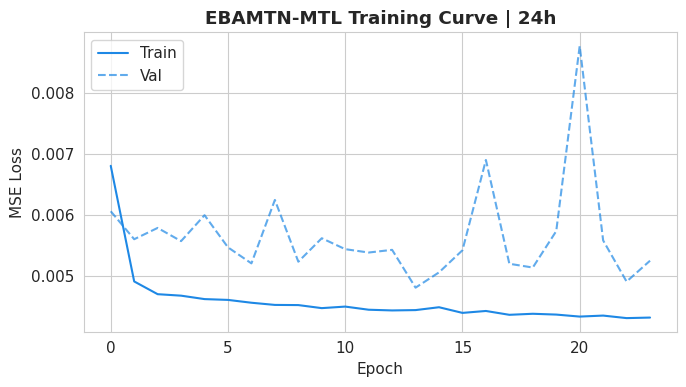

Saved: mtl_training_curve.png


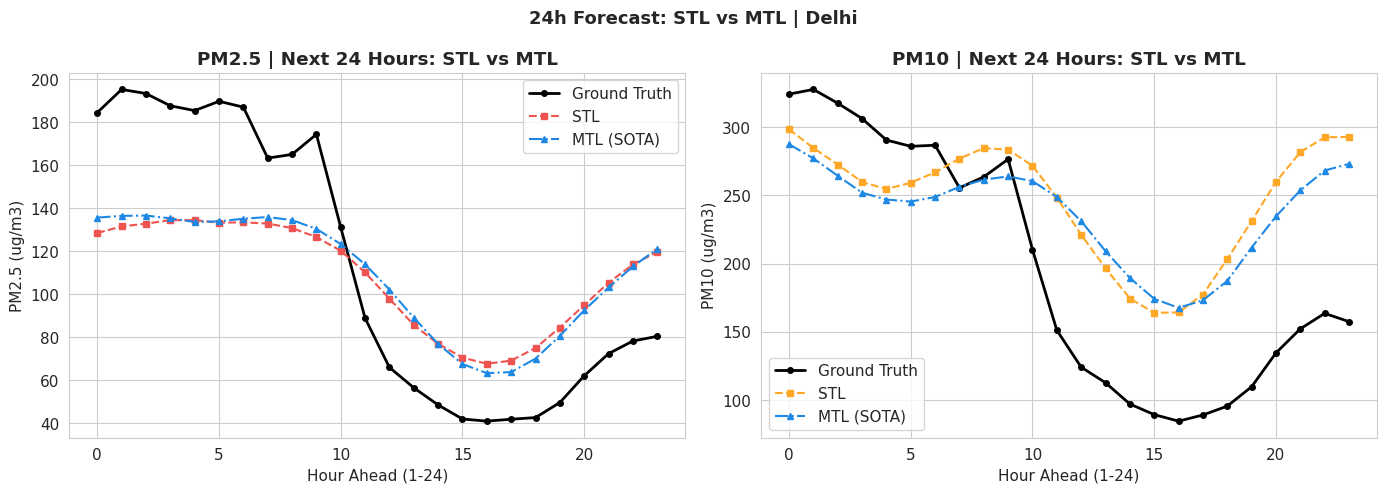

Saved: mtl_vs_stl_24h_sample.png


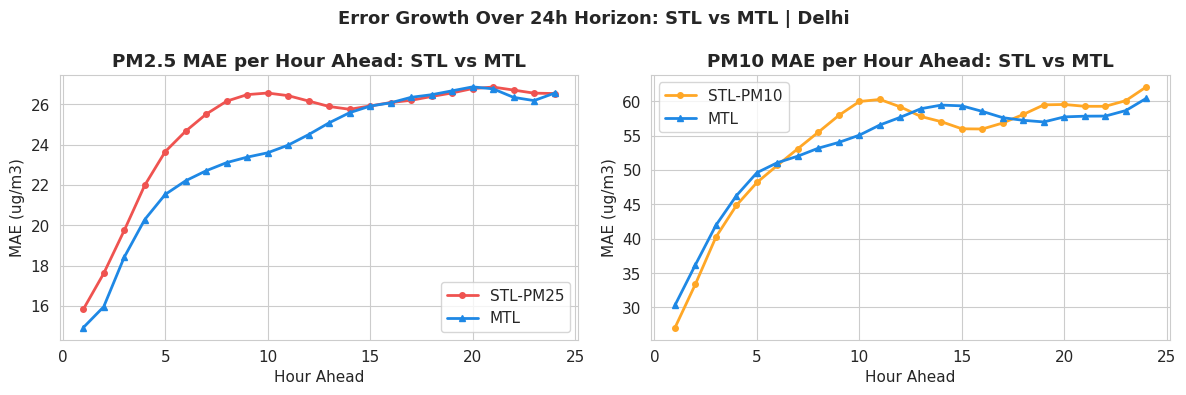

Saved: mae_per_hour_comparison.png


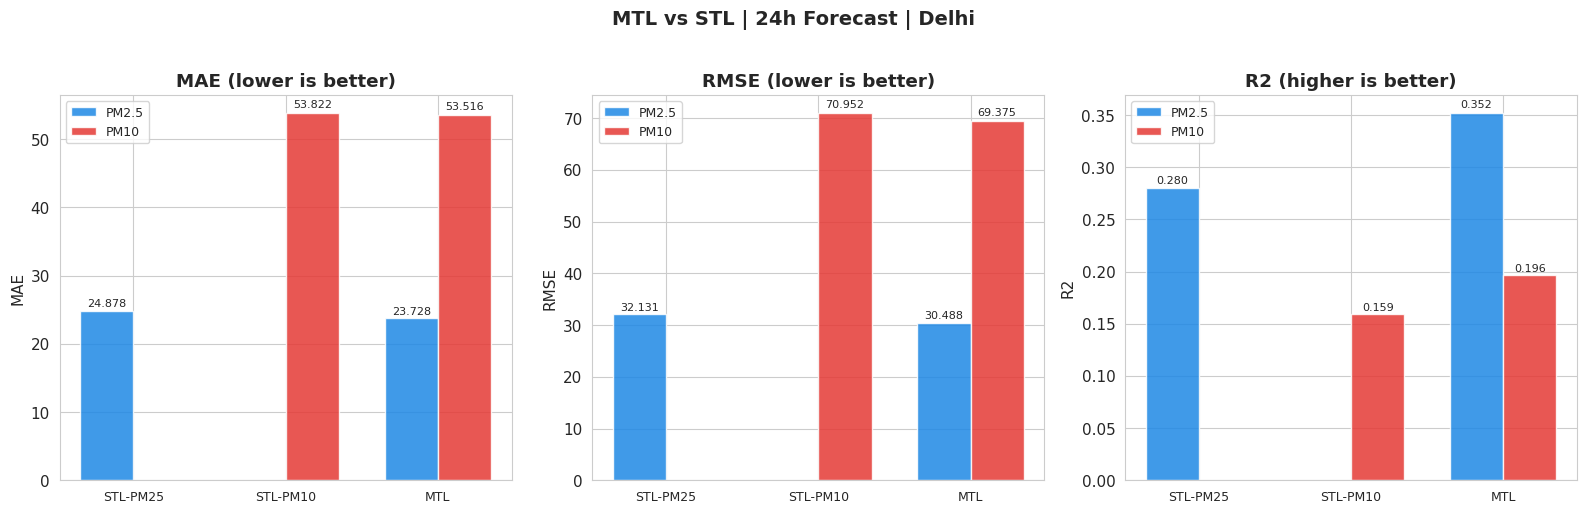

Saved: mtl_vs_stl_metrics.png


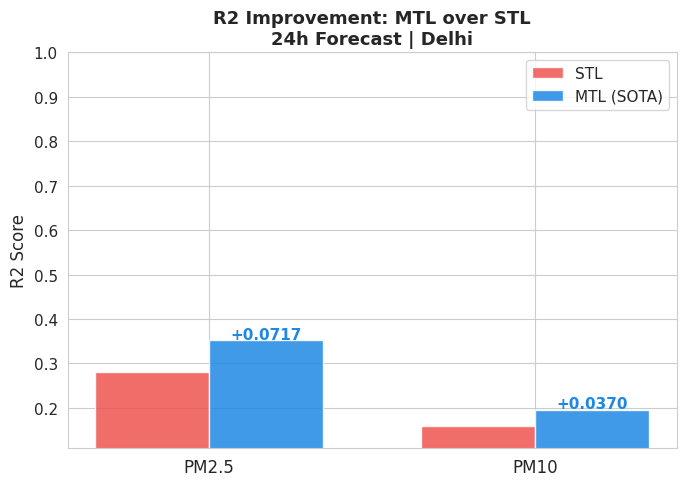

Saved: r2_improvement.png

All done! MTL vs STL 24h comparison complete.


In [ ]:
from tqdm.auto import tqdm

class MTLHead(nn.Module):
    def __init__(self, in_dim, horizon, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, horizon)
        )
    def forward(self, x): return self.net(x)

class EBAMTN_MTL(nn.Module):
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn = MultiScaleTCN(n_feat, cfg["tcn_channels"], cfg["dropout"])
        self.bilstm = BiLSTMAttention(n_feat, cfg["bilstm_hidden"],
                                         cfg["bilstm_layers"], cfg["num_heads"], cfg["dropout"])
        self.fusion = GatedFusion(sum(cfg["tcn_channels"]), cfg["bilstm_hidden"]*2,
                                     cfg["fusion_dim"], cfg["dropout"])
        self.head_pm25 = MTLHead(cfg["fusion_dim"], cfg["horizon"])
        self.head_pm10 = MTLHead(cfg["fusion_dim"], cfg["horizon"])

    def forward(self, x):
        fused = self.fusion(self.tcn(x), self.bilstm(x))
        return self.head_pm25(fused), self.head_pm10(fused)

def train_mtl(model, tr_loader, va_loader, cfg):
    opt = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    mse = nn.MSELoss()
    best_val,best_w,wait = np.inf,None,0
    tr_hist,va_hist = [],[]

    pbar = tqdm(range(1, cfg["epochs"]+1), desc="MTL Training")
    for ep in pbar:
        model.train(); tl=0.0
        for xb,yb in tr_loader:
            xb,yb = xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad()
            p25,p10 = model(xb)
            true25 = yb[:,:,0]
            true10 = yb[:,:,1]
            loss = cfg["alpha"]*mse(p25,true25) + (1-cfg["alpha"])*mse(p10,true10)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step(); tl+=loss.item()*len(xb)
        sch.step(); tl/=len(tr_loader.dataset)

        model.eval(); vl=0.0
        with torch.no_grad():
            for xb,yb in va_loader:
                xb,yb=xb.to(DEVICE),yb.to(DEVICE)
                p25,p10=model(xb)
                vl+=(cfg["alpha"]*mse(p25,yb[:,:,0])+(1-cfg["alpha"])*mse(p10,yb[:,:,1])).item()*len(xb)
        vl/=len(va_loader.dataset)
        tr_hist.append(tl); va_hist.append(vl)
        pbar.set_postfix(train=f"{tl:.5f}", val=f"{vl:.5f}")

        if vl<best_val: best_val,best_w,wait=vl,deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=cfg["patience"]: print(f"  Early stop @ ep {ep}"); break

    model.load_state_dict(best_w)
    return model, tr_hist, va_hist

@torch.no_grad()
def predict_mtl(model, loader):
    model.eval(); p25,p10,t25,t10=[],[],[],[]
    for xb,yb in loader:
        a,b=model(xb.to(DEVICE))
        p25.append(a.cpu().numpy()); p10.append(b.cpu().numpy())
        t25.append(yb[:,:,0].numpy()); t10.append(yb[:,:,1].numpy())
    return (np.concatenate(p25),np.concatenate(p10),
            np.concatenate(t25),np.concatenate(t10))

print("="*60)
print("EBAMTN-MTL | 24-Hour Forecasting | Delhi")
print("="*60)

print("\nTraining EBAMTN-MTL (PM2.5 + PM10 jointly, 24h ahead) ...")
mtl_model = EBAMTN_MTL(n_feat, CFG).to(DEVICE)
mtl_model,mtl_tl,mtl_vl = train_mtl(mtl_model, tr_loader, va_loader, CFG)

p25,p10,t25,t10 = predict_mtl(mtl_model, te_loader)
p25_r = inv_horizon(p25, scalers["pm25"]); t25_r = inv_horizon(t25, scalers["pm25"])
p10_r = inv_horizon(p10, scalers["pm10"]); t10_r = inv_horizon(t10, scalers["pm10"])

m25 = get_metrics(t25_r, p25_r)
m10 = get_metrics(t10_r, p10_r)
mtl_results = {"EBAMTN-MTL": {"pm25": m25, "pm10": m10}}
mtl_preds = {"EBAMTN-MTL": {"p25":p25_r,"p10":p10_r,"t25":t25_r,"t10":t10_r}}

print(f"  PM2.5 -> MAE={m25['MAE']:.3f}  RMSE={m25['RMSE']:.3f}  R2={m25['R2']:.4f}")
print(f"  PM10  -> MAE={m10['MAE']:.3f}  RMSE={m10['RMSE']:.3f}  R2={m10['R2']:.4f}")

all_results = {**stl_results, **mtl_results}
print("\n"+"="*72)
print(f"{'Model':<22} {'PM2.5 MAE':>10} {'PM2.5 RMSE':>11} {'PM2.5 R2':>9}"
      f"  {'PM10 MAE':>9} {'PM10 RMSE':>10} {'PM10 R2':>8}")
print("-"*72)
for name,res in all_results.items():
    m25r=res["pm25"]; m10r=res["pm10"]
    s25=(f"{m25r['MAE']:>10.3f} {m25r['RMSE']:>11.3f} {m25r['R2']:>9.4f}"
         if m25r else f"{'---':>10} {'---':>11} {'---':>9}")
    s10=(f"{m10r['MAE']:>9.3f} {m10r['RMSE']:>10.3f} {m10r['R2']:>8.4f}"
         if m10r else f"{'---':>9} {'---':>10} {'---':>8}")
    print(f"{name:<22} {s25}  {s10}")
print("="*72)

C = {"STL25":"#EF5350","STL10":"#FFA726","MTL":"#1E88E5"}

fig,ax=plt.subplots(figsize=(7,4))
ax.plot(mtl_tl,label="Train",color=C["MTL"])
ax.plot(mtl_vl,label="Val",  color=C["MTL"],ls="--",alpha=0.7)
ax.set_title("EBAMTN-MTL Training Curve | 24h",fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend()
plt.tight_layout()
plt.savefig("mtl_training_curve.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: mtl_training_curve.png")

fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
ax.plot(t25_r[0], color="black", lw=2, label="Ground Truth", marker="o", ms=4)
ax.plot(stl_preds["EBAMTN-STL-PM25"]["p25"][0], color=C["STL25"], lw=1.5, ls="--", label="STL", marker="s", ms=4)
ax.plot(p25_r[0], color=C["MTL"], lw=1.5, ls="-.", label="MTL (SOTA)", marker="^", ms=4)
ax.set_title("PM2.5 | Next 24 Hours: STL vs MTL", fontweight="bold")
ax.set_xlabel("Hour Ahead (1-24)"); ax.set_ylabel("PM2.5 (ug/m3)"); ax.legend()
ax=axes[1]
ax.plot(t10_r[0], color="black", lw=2, label="Ground Truth", marker="o", ms=4)
ax.plot(stl_preds["EBAMTN-STL-PM10"]["p10"][0], color=C["STL10"], lw=1.5, ls="--", label="STL", marker="s", ms=4)
ax.plot(p10_r[0], color=C["MTL"], lw=1.5, ls="-.", label="MTL (SOTA)", marker="^", ms=4)
ax.set_title("PM10 | Next 24 Hours: STL vs MTL", fontweight="bold")
ax.set_xlabel("Hour Ahead (1-24)"); ax.set_ylabel("PM10 (ug/m3)"); ax.legend()
plt.suptitle("24h Forecast: STL vs MTL | Delhi",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("mtl_vs_stl_24h_sample.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: mtl_vs_stl_24h_sample.png")

fig,axes=plt.subplots(1,2,figsize=(12,4))
mae_stl25 = get_metrics_per_hour(stl_preds["EBAMTN-STL-PM25"]["t25"],
                                  stl_preds["EBAMTN-STL-PM25"]["p25"])
mae_mtl25 = get_metrics_per_hour(t25_r, p25_r)
mae_stl10 = get_metrics_per_hour(stl_preds["EBAMTN-STL-PM10"]["t10"],
                                  stl_preds["EBAMTN-STL-PM10"]["p10"])
mae_mtl10 = get_metrics_per_hour(t10_r, p10_r)
hrs = range(1,25)
axes[0].plot(hrs,mae_stl25,color=C["STL25"],lw=2,marker="o",ms=4,label="STL-PM25")
axes[0].plot(hrs,mae_mtl25,color=C["MTL"],  lw=2,marker="^",ms=4,label="MTL")
axes[0].set_title("PM2.5 MAE per Hour Ahead: STL vs MTL",fontweight="bold")
axes[0].set_xlabel("Hour Ahead"); axes[0].set_ylabel("MAE (ug/m3)"); axes[0].legend()
axes[1].plot(hrs,mae_stl10,color=C["STL10"],lw=2,marker="o",ms=4,label="STL-PM10")
axes[1].plot(hrs,mae_mtl10,color=C["MTL"],  lw=2,marker="^",ms=4,label="MTL")
axes[1].set_title("PM10 MAE per Hour Ahead: STL vs MTL",fontweight="bold")
axes[1].set_xlabel("Hour Ahead"); axes[1].set_ylabel("MAE (ug/m3)"); axes[1].legend()
plt.suptitle("Error Growth Over 24h Horizon: STL vs MTL | Delhi",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("mae_per_hour_comparison.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: mae_per_hour_comparison.png")


fig,axes=plt.subplots(1,3,figsize=(16,5))
keys=list(all_results.keys()); x,w=np.arange(len(keys)),0.35
for ax,metric,better in zip(axes,["MAE","RMSE","R2"],["lower","lower","higher"]):
    v25=[all_results[k]["pm25"][metric] if all_results[k]["pm25"] else np.nan for k in keys]
    v10=[all_results[k]["pm10"][metric] if all_results[k]["pm10"] else np.nan for k in keys]
    b1=ax.bar(x-w/2,v25,w,label="PM2.5",color="#1E88E5",alpha=0.85)
    b2=ax.bar(x+w/2,v10,w,label="PM10", color="#E53935",alpha=0.85)
    for b in list(b1)+list(b2):
        v=b.get_height()
        if not np.isnan(v):
            ax.text(b.get_x()+b.get_width()/2,v*1.01,f"{v:.3f}",
                    ha="center",va="bottom",fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([k.replace("EBAMTN-","") for k in keys],fontsize=9)
    ax.set_title(f"{metric} ({better} is better)",fontweight="bold")
    ax.set_ylabel(metric); ax.legend(fontsize=9)
plt.suptitle("MTL vs STL | 24h Forecast | Delhi",fontsize=14,fontweight="bold",y=1.02)
plt.tight_layout()
plt.savefig("mtl_vs_stl_metrics.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: mtl_vs_stl_metrics.png")

fig,ax=plt.subplots(figsize=(7,5))
stl25_r2=stl_results["EBAMTN-STL-PM25"]["pm25"]["R2"]
stl10_r2=stl_results["EBAMTN-STL-PM10"]["pm10"]["R2"]
mtl25_r2=mtl_results["EBAMTN-MTL"]["pm25"]["R2"]
mtl10_r2=mtl_results["EBAMTN-MTL"]["pm10"]["R2"]
x,w=np.arange(2),0.35
ax.bar(x-w/2,[stl25_r2,stl10_r2],w,label="STL",color="#EF5350",alpha=0.85)
ax.bar(x+w/2,[mtl25_r2,mtl10_r2],w,label="MTL (SOTA)",color=C["MTL"],alpha=0.85)
for i,(s,m) in enumerate(zip([stl25_r2,stl10_r2],[mtl25_r2,mtl10_r2])):
    gain=m-s
    ax.annotate(f"{'+' if gain>=0 else ''}{gain:.4f}",
                xy=(i+w/2,m+0.003),ha="center",fontsize=11,color=C["MTL"],fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(["PM2.5","PM10"],fontsize=12)
ax.set_ylabel("R2 Score",fontsize=12)
ax.set_ylim(max(0,min(stl25_r2,stl10_r2,mtl25_r2,mtl10_r2)-0.05),1.0)
ax.set_title("R2 Improvement: MTL over STL\n24h Forecast | Delhi",
             fontweight="bold",fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("r2_improvement.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: r2_improvement.png")

print("\nAll done! MTL vs STL 24h comparison complete.")
